<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [1]:
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc

import sdg4varselect as sdg
import sdg4varselect.new_plot as sdgplt

## Model sepecification
Le modèle que l'on souhaite étudier est le suivant : 

$$Y_{i,j} = \frac{\varphi_{1,i}}{1+ \exp\left(\frac{-(t_{i,j}- \xi_i}\tau\right)}$$

Où $\xi_i = \beta^T X + \varphi_{2,i}$ et $\varphi  \sim \mathcal N(\mu, \Gamma^2)$

Le code ci-dessous le définie pour python.

In [2]:
import functools
from jax import jit

import parametrization_cookbook.jax as pc


from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class LogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractHDModel.__init__(self, P=P)
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init_parametrization(self):
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(2000, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = supremum
        phi2 = midpoint
        tau = growth rate

        phi1/ ( 1+ exp((phi2 + beta^T X -t)/tau))

        """
        ksi = cov @ params.beta + phi2

        out = phi1[:, None] / (1 + jnp.exp(-(times - ksi[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        def interval(a, b, n_pts):
            return a + jnp.arange(0, n_pts) * (b - a) / n_pts

        interval_percentage = [(0, 0.3), (0.35, 0.5), (0.6, 1.0)]
        A, B = 150, 3000
        BsubA = B - A
        time = jnp.array([])
        for a, b in interval_percentage:
            time = jnp.concatenate(
                [
                    time,
                    interval(
                        A + a * BsubA, A + b * BsubA, self.J // len(interval_percentage)
                    ),
                ]
            )

        time = jnp.repeat(time[None, :], self.N, axis=0)
        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

In [3]:
import pandas as pd
from sdg4varselect.outputs import TestResults, MultiRunRes
from sdg4varselect._regularization_function import eBIC


seed_name = "S(1, 100)"
m = LogisticMixedEffectsModel
config = [
    {"N": 100, "J": 15, "P": 500},
    {"N": 200, "J": 15, "P": 500},
    {"N": 100, "J": 15, "P": 1000},
    {"N": 200, "J": 15, "P": 1000},
]
update_ebic = False
if update_ebic:
    runres = []
    for c in config:
        myModel = m(N=c["N"], J=15, P=c["P"])
        multires = MultiRunRes.load(m(**c), "files", filename_add_on=seed_name)

        print(multires[0].ebic)

        for i in range(len(multires)):
            print(i)
            reg = multires[i]  # .standardize()

            ebic = []
            # bic = []
            for step in range(reg.last_theta.shape[0]):
                x = jnp.array([r.last_theta[step, -myModel.P :] for r in reg])
                t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

                ebic.append(
                    eBIC(
                        t,
                        jnp.array([r.likelihood[step] for r in reg]),
                        myModel.N * (1 + myModel.J),
                    )
                )

                # bic.append(
                #     BIC(
                #         t,
                #         jnp.array([r.likelihood[step] for r in reg]),
                #         myModel.N * (1 + myModel.J),
                #     )
                # )
            reg.ebic = jnp.array(ebic)
            # reg.bic = jnp.array(bic)
        runres.append(multires)

    results = TestResults(runres, config)
    for i in range(len(runres)):
        c = config[i]
        runres[i].save(m(N=c["N"], J=15, P=c["P"]), filename_add_on=seed_name)


results = TestResults(
    [TestResults.load(m(**c), "", filename_add_on=seed_name) for c in config],
    config,
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])


pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


LogisticMEM_N100_J15_P500_S(1, 100) LOADED !
LogisticMEM_N200_J15_P500_S(1, 100) LOADED !
LogisticMEM_N100_J15_P1000_S(1, 100) LOADED !
LogisticMEM_N200_J15_P1000_S(1, 100) LOADED !
chrono = ['5 days, 11:50:46.750728', '10 days, 18:01:07.775926', '27 days, 23:40:05.614922', '15 days, 21:42:16.813729']
[100, 100, 100, 100]


,by fit,by estimation ( 20.0 fits)
"N = 100, P = 500",0:03:57.323375,13:11:04.675073
"N = 200, P = 500",0:07:44.433888,"1 day, 1:48:06.777593"
"N = 100, P = 1000",0:20:09.002807,"2 days, 19:10:00.561492"
"N = 200, P = 1000",0:11:27.068407,"1 day, 14:10:13.681373"


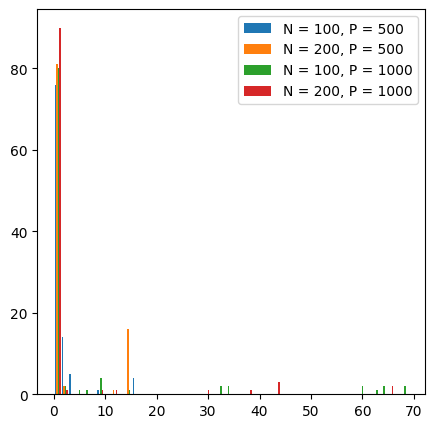

In [4]:
scenarios_labels = [
    f"{n}, {p}"
    for n, p in zip(
        results.get_scenarios_labels("N"), results.get_scenarios_labels("P")
    )
]

dt = jnp.array([[t.chrono.total_seconds() / 60 / 60 for t in res] for res in results])
ax = sdgplt.ax(5, 5)
h = ax.hist(dt, label=scenarios_labels, bins=50)
ax.legend()
# _ = ax.set_xticks(h[1]+1,h[1])

In [5]:
myModel = m(200, 15, P=max([c["P"] for c in results.config]))

p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([40, 200])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)

params_names = (
    ["$\\mu_1$", "$\\mu_2$", "$\\tau$"]
    + [f"$\\gamma^2_{{{1+i//2},{1+i%2}}}$" for i in range(2 * 2)]
    + ["$\\sigma^2$"]
    + [f"$\\beta_{1+i}$" for i in range(myModel.P)]
)

Regularization path check

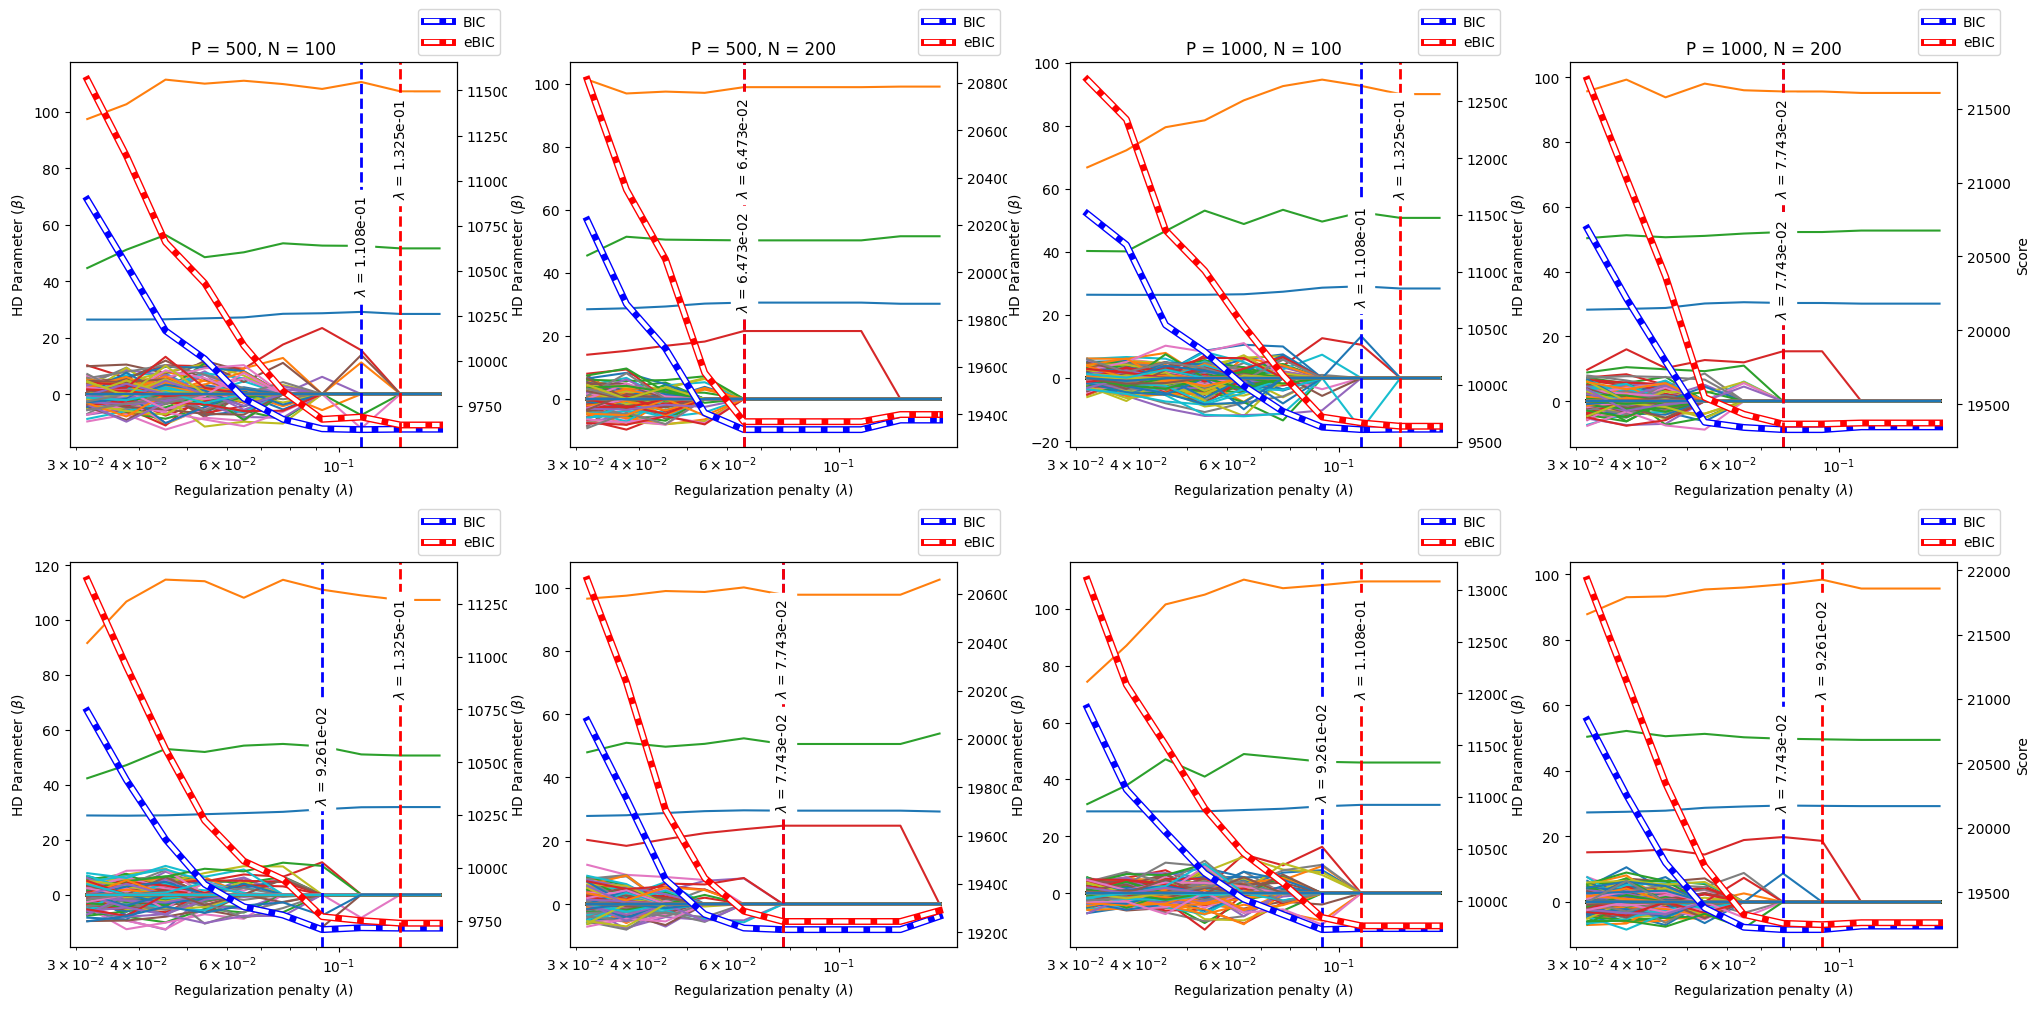

In [6]:
import numpy as np

r = results  # .filter(P = 1000,N=200, keep_type=True)

fig = sdgplt.figure(10, 5 * len(r))
subfigs = fig.subfigures(2, len(r))
if len(subfigs.shape) == 1:
    subfigs = np.array([subfigs]).T

for j in range(subfigs.shape[1]):
    for i in range(subfigs.shape[0]):
        reg_res = r[j][i].standardize()
        fig = sdgplt.plot_reg_path(
            reg_res=reg_res,
            D=7,
            fig=subfigs[i][j],
        )
        subfigs[i][j].axes[0].set_title("")
    subfigs[0][j].axes[0].set_title(r.get_scenarios_labels(["P", "N"])[j])

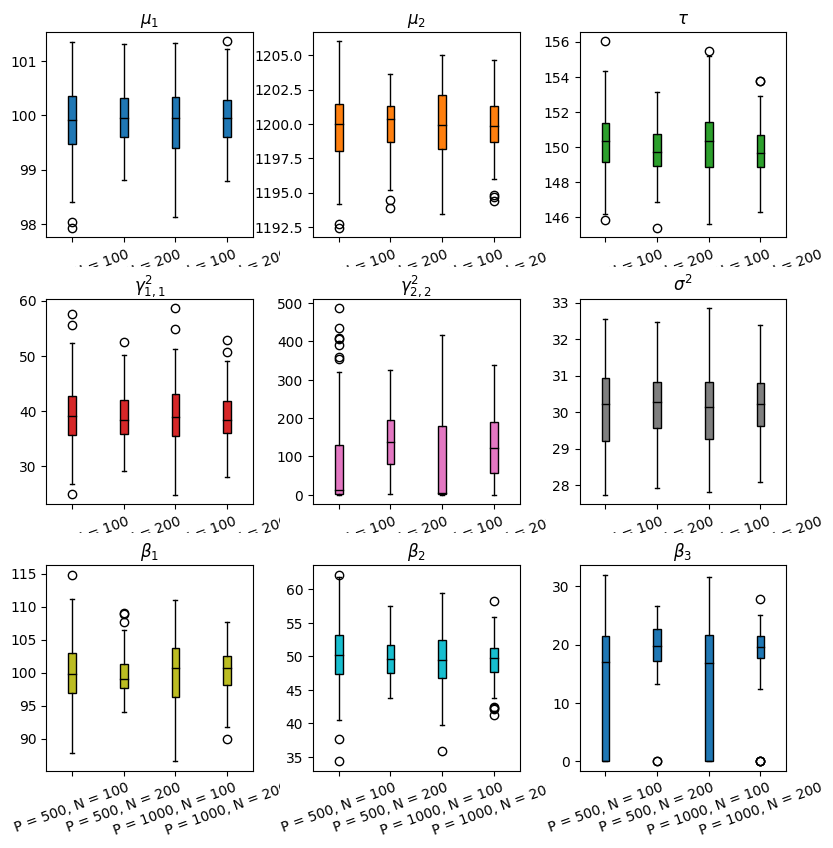

In [11]:
id_to_plot = jnp.array([0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12])
scenarios_labels = results.get_scenarios_labels(["P", "N"])

fig = sdgplt.boxplot_estimation(
    x=results.last_theta[:, :, -1].T,
    id_to_plot=id_to_plot,
    titles=params_names,
    xlabels=scenarios_labels,
    fig=sdgplt.figure(8, 8),
    nrow=3,
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=20)

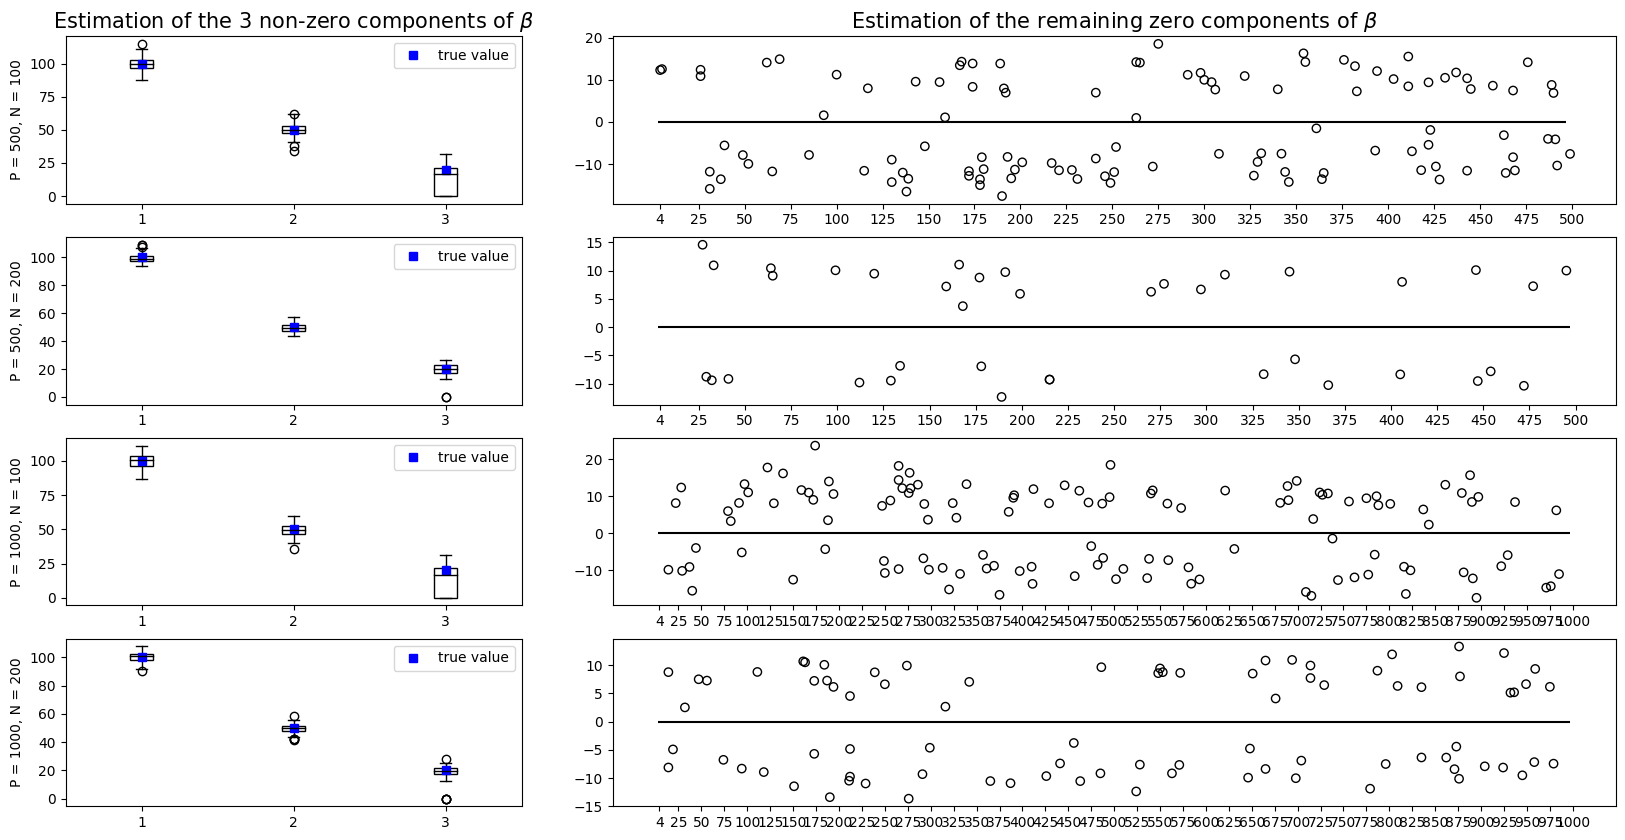

In [12]:
from sdg4varselect.plot import plot_2_panel_selected_theta_hd

_ = plot_2_panel_selected_theta_hd(
    results,
    myModel.hstack_params(p_star),
    scenarios_labels,
    dim_ld=8,
    fig=sdgplt.figure(10, 20),
    theta_name="$\\beta$",
)

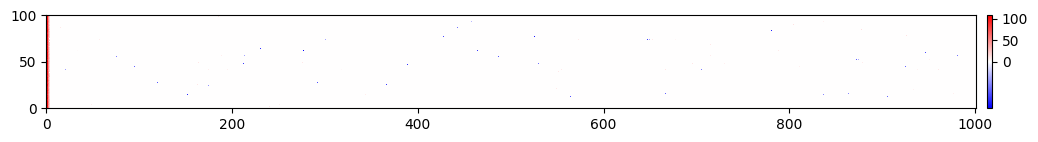

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

theta = jnp.array(
    [jnp.array([(res[-1][7:]) for res in test]) for test in results.last_theta]
)[-1]

params_star_HD = p_star[9 : 9 + theta.shape[1]] != 0
correct_model = jnp.array([params_star_HD == t for t in theta]).mean(axis=1)

correct_model_sum = (
    jnp.array(
        [
            jnp.array(correct_model == 1).sum(),
            jnp.logical_and(0.9 <= correct_model, correct_model < 1).sum(),
            jnp.array(correct_model < 0.9).sum(),
        ]
    )
    / correct_model.shape[0]
)


fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)


def meshgrid(ax, dt):
    x_abs = 0.5 + np.arange(dt.shape[1])
    y_ord = 0.5 + np.arange(dt.shape[0])
    x, y = np.meshgrid(x_abs, y_ord)

    vmin = dt.min() if dt.min() < 0 else -0.001
    vmax = dt.max() if dt.max() > 0 else 0.0001

    colormesh = ax.pcolormesh(
        x,
        y,
        dt,
        cmap=plt.colormaps["bwr"],
        norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    )

    ax.set_aspect("equal")

    # cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    cb = fig.colorbar(colormesh, ax=ax)  # , location="right")

    return ax, cb


ax, cb = meshgrid(ax, theta[np.argsort(correct_model), :])
cb_pos = cb.ax.get_position()
ax_pos = ax.get_position()
cb.ax.set_position([ax_pos.xmax * 1.01, ax_pos.ymin, ax_pos.width, ax_pos.height])

## RMSE estimation P = 500

In [ ]:
import numpy as np


def table_rmse_article(results):
    # last_theta_estim =
    params_names = np.array(
        [
            "$\\mu$",
            "$\\psi_1$",
            "$\\psi_2$",
            "$\\gamma^2_1$",
            "$\\gamma^2_{12}$",
            "$\\gamma^2_{21}$",
            "$\\gamma^2_2$",
            "$\\sigma^2$",
            "$\\beta$",
        ]
        + [f"$\\beta_{i+1}$" for i in range(myModel.P)]
    )

    df = []
    for i in range(len(results)):
        pd_df = sdgplt.get_dataframe_results(
            results[i].last_theta[
                :, -1, : myModel.DIM_LD + 3
            ],  # last_theta_estim[:, : myModel.DIM_LD],
            myModel.hstack_params(p_star)[: myModel.DIM_LD + 3],
            params_names[: myModel.DIM_LD + 3],
        )

        pd_df = pd_df.drop("real value", axis=1)
        # pd_df = pd_df.drop("RRMSE", axis=1)
        # pd_df= pd_df.drop("RMSE", axis = 1)
        pd_df = pd_df.drop("mean", axis=1)
        pd_df = pd_df.drop("variance", axis=1)

        df.append(pd_df)

    col = pd.MultiIndex.from_arrays(
        [
            np.repeat([f'{c["N"]}' for c in results.config], len(pd_df.index)),
            np.tile(pd_df.index, len(results)),
        ]
    )
    col = sum([[l, l] for l in results.get_scenarios_labels("P")], [])

    pd_df = pd.concat(df, axis=1)
    print(pd_df.index)

    pd_df = pd.DataFrame(
        pd_df.to_numpy(),
        columns=pd.MultiIndex.from_arrays(
            [
                np.repeat([f" N = {results.config[0]['N']}"], len(pd_df.columns)),
                col,  # pd_df.columns,
            ]
        ),
        index=pd_df.index,
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    return pd_df.style.format("{:.2f}".format)


table_rmse_article(results)  # .filter(N=200, keep_type=True).sort("N"))

### Variable selection numerical proof

In [ ]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)
print(support_star.shape)


def get_support(x):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :])
print(multi_support.shape)

In [ ]:
def hist(results):
    multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :])
    ax = sdgplt.get_ax(4, 4)

    dt = jnp.nansum(multi_support, axis=-1)
    # print(dt)
    bins = jnp.arange(dt.min(), dt.max())
    h = ax.hist(dt, bins, label=results.get_scenarios_labels("P"))
    # print(h)
    ax.set_xticks(h[1] + 0.5, h[1])
    ax.legend()


hist(results.filter(N=100).sort("P"))
hist(results.filter(N=200).sort("P"))

In [ ]:
def table_accuracy_article(results):

    support_star = get_support_star(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    multi_support = get_support(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    ds = jnp.abs(multi_support - support_star)
    # TP/total P
    TP = jnp.nansum(ds[:, :, :3], axis=-1)
    sensitivity = 1 - jnp.nanmean(ds[:, :, :3], axis=-1)
    # TN / total N
    TN = jnp.nansum(ds[:, :, 3:], axis=-1)
    specificity = 1 - jnp.nanmean(ds[:, :, 3:], axis=-1)
    # (TP+TN)/dim
    accuracy = 1 - jnp.nansum(ds, axis=-1)
    accuracy = 1 - jnp.nanmean(ds, axis=-1)

    dx = jnp.abs(results.last_theta[:, :, -1, myModel.DIM_LD :] - p_star.beta)
    L1 = jnp.nansum(dx, axis=-1)
    L2 = jnp.sqrt(jnp.nansum(dx**2, axis=-1))

    x = jnp.array([sensitivity, specificity, accuracy, L1, L2])
    y = [x.mean(axis=-1), jnp.sqrt(x.var(axis=-1))]
    df = jnp.column_stack(
        [jnp.column_stack([y[0][i], y[1][i]]) for i in range(x.shape[0])]
    )
    df = jnp.concatenate([jnp.stack([y[0].T[i], y[1].T[i]]) for i in range(x.shape[1])])

    col = [
        "sensitivity",
        "specificity",
        "accuracy",
        "L1",
        "L2",
    ]
    # col = pd.MultiIndex.from_arrays(
    #     [ sum([[i]*2 for i in range(5)],[]),
    #         ["mean", "var"] * 5,
    #     ]
    # )

    pd_df = pd.DataFrame(
        df,
        columns=col,
        index=sum([[f'N = {c["N"]}, P = {c["P"]}', ""] for c in results.config], []),
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    # .style.format(["{:.3%}".format, "{:.1}".format]*5)
    # {
    #     "sensitivity": "{:.3%}".format,
    #     "specificity": "{:.3%}".format,
    #     "accuracy": "{:.3%}".format,
    #     "L1": "{:.1f}".format,
    #     "L2": "{:.1f}".format,
    # }
    return pd_df.style.format("{:.2}".format)


table_accuracy_article(results.sort("P"))
# table_accuracy_article(results.filter(P=500).sort("N"))

In [ ]:

support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)

multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)

all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T

pd.DataFrame(score_support, col = ["Exact", "Over"], index = )


In [ ]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

scenarios_labels = sum([[f'N = {c["N"]}, P = {c["P"]}'] for c in results.config], [])

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )